In [22]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
import cartopy 
import cmocean 
import cartopy.crs as ccrs 

In [ ]:
foccus = '/lustre/storeB/project/fou/hi/foccus'
filepath = 'malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res/2024-04-02_.ckpt_e010_s020000.nc' #inference results from my own run

#inference results 

In [3]:
ds = xr.open_dataset(f'{foccus}/{filepath}')

In [4]:
ds

<xarray.Dataset> Size: 5GB
Dimensions:            (X: 1148, Y: 2747, time: 17)
Coordinates:
  * X                  (X) float64 9kB 0.0 800.0 1.6e+03 ... 9.168e+05 9.176e+05
  * Y                  (Y) float64 22kB 0.0 800.0 ... 2.196e+06 2.197e+06
  * time               (time) datetime64[ns] 136B 2024-04-02 ... 2024-04-04
Data variables: (12/26)
    latitude           (X, Y) float32 13MB ...
    longitude          (X, Y) float32 13MB ...
    h                  (time, X, Y) float32 214MB ...
    salinity_0         (time, X, Y) float32 214MB ...
    sea_mask           (time, X, Y) float32 214MB ...
    temperature_0      (time, X, Y) float32 214MB ...
    ...                 ...
    rain               (time, X, Y) float32 214MB ...
    river_binary_mask  (time, X, Y) float32 214MB ...
    sin_julian_day     (time, X, Y) float32 214MB ...
    sin_latitude       (time, X, Y) float32 214MB ...
    sin_local_time     (time, X, Y) float32 214MB ...
    sin_longitude      (time, X, Y) float32 214MB ...

In [5]:
#okay so plotting f / h seems simple enough, because we already have them both - but do we need to interpolate?? maybe not ..

f = ds.f
h = ds.h 

In [11]:
#then cut out an area - it is of interst to study either Vestlandet or Lofoten as discussed with Matheusz
#We expect the bottom topography to impact the surface currents. We should see that f/h follows the ocean currents u and v

import pyresample
#select an area
lon_min, lon_max = 11.83083, 15.59072
lat_min, lat_max = 67.41791, 69.20699


lon_ulc, lon_llc = 11.83, 11.83
lon_lrc, lon_urc = 15.59, 15.59
lat_urc, lat_ulc = 69.21, 69.21
lat_llc, lat_lrc = 67.41, 67.41

#lon_re = ds_norkyst.lon.astype(np.float64)
#lat_re = ds_norkyst.lat.astype(np.float64)

ds_grid = pyresample.geometry.GridDefinition(lons=ds.longitude.values, lats = ds.latitude.values)
pos_geo = pyresample.geometry.SwathDefinition(lons=[lon_llc, lon_lrc, lon_urc, lon_ulc], lats=[lat_llc, lat_lrc, lat_urc, lat_ulc])

_, valid_output_index, index_array, distance_array = pyresample.kd_tree.get_neighbour_info(
                                                    source_geo_def = ds_grid,
                                                    target_geo_def = pos_geo,
                                                    radius_of_influence = 800,
                                                    neighbours = 1)

index_array_2d = np.unravel_index(index_array, ds_grid.shape)

(x_indices,y_indices) =  np.array([index_array_2d[0][0], index_array_2d[0][1], index_array_2d[0][2], index_array_2d[0][3]]), np.array([index_array_2d[1][0], index_array_2d[1][1], index_array_2d[1][2], index_array_2d[1][3]])
x_min, x_max = x_indices.min(), x_indices.max()
y_min, y_max = y_indices.min(), y_indices.max()

#make sure its correct
print(f'X min: {x_min}, X max: {x_max}')
print(f'Y min: {y_min}, Y max: {y_max}')

Lofoten = ds.isel(Y=slice(y_min, y_max+1), X = slice(x_min, x_max +1))

X min: 572, X max: 862
Y min: 1680, Y max: 1986


In [12]:
Lofoten

<xarray.Dataset> Size: 147MB
Dimensions:            (X: 291, Y: 307, time: 17)
Coordinates:
  * X                  (X) float64 2kB 4.576e+05 4.584e+05 ... 6.896e+05
  * Y                  (Y) float64 2kB 1.344e+06 1.345e+06 ... 1.589e+06
  * time               (time) datetime64[ns] 136B 2024-04-02 ... 2024-04-04
Data variables: (12/26)
    latitude           (X, Y) float32 357kB 66.75 66.76 66.77 ... 69.83 69.83
    longitude          (X, Y) float32 357kB 14.4 14.42 14.43 ... 12.96 12.97
    h                  (time, X, Y) float32 6MB ...
    salinity_0         (time, X, Y) float32 6MB ...
    sea_mask           (time, X, Y) float32 6MB ...
    temperature_0      (time, X, Y) float32 6MB ...
    ...                 ...
    rain               (time, X, Y) float32 6MB ...
    river_binary_mask  (time, X, Y) float32 6MB ...
    sin_julian_day     (time, X, Y) float32 6MB ...
    sin_latitude       (time, X, Y) float32 6MB ...
    sin_local_time     (time, X, Y) float32 6MB ...
    sin_longitude      (time, X, Y) float32 6MB ...

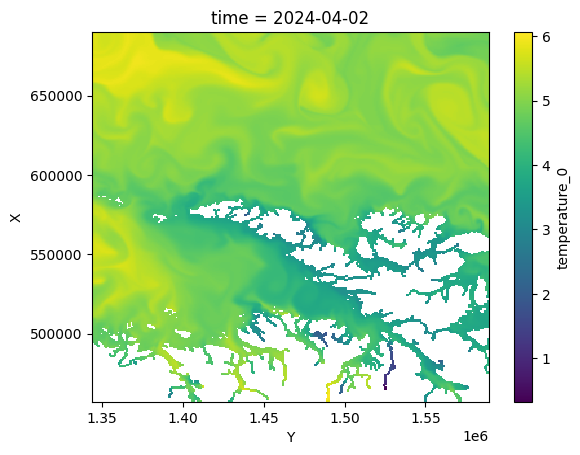

In [19]:
#just a quick check that it works
Lofoten.temperature_0.isel(time = 0).plot()

In [71]:
h_L = Lofoten.h 
f_L = Lofoten.f


In [75]:
f_h = f.values/h.values
f_h[0,slice(x_min,x_max),slice(y_min, y_max)]

array([[1.34002939e-05, 1.34009051e-05, 1.34015163e-05, ...,
        1.35755299e-05, 1.35760756e-05, 1.35766195e-05],
       [1.34007114e-05, 1.34013226e-05, 1.34019338e-05, ...,
        1.35759547e-05, 1.35764985e-05, 1.35770433e-05],
       [1.34011307e-05, 1.34017419e-05, 1.34023530e-05, ...,
        1.35763785e-05, 1.35769224e-05, 1.35774662e-05],
       ...,
       [1.44433869e-07, 1.43426007e-07, 1.42319649e-07, ...,
        4.85991656e-08, 4.86362488e-08, 4.86783094e-08],
       [1.39596850e-07, 1.38451668e-07, 1.37171170e-07, ...,
        4.86038232e-08, 4.86375349e-08, 4.86765153e-08],
       [1.35197908e-07, 1.33986475e-07, 1.32607354e-07, ...,
        4.86209117e-08, 4.86511027e-08, 4.86866512e-08]],
      shape=(290, 306), dtype=float32)

In [161]:
step = 7
min_l = -0.5e-5 
max_l = 1.44e-5
custom = np.linspace(min_l, max_l, 20)

/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/cartopy/mpl/geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


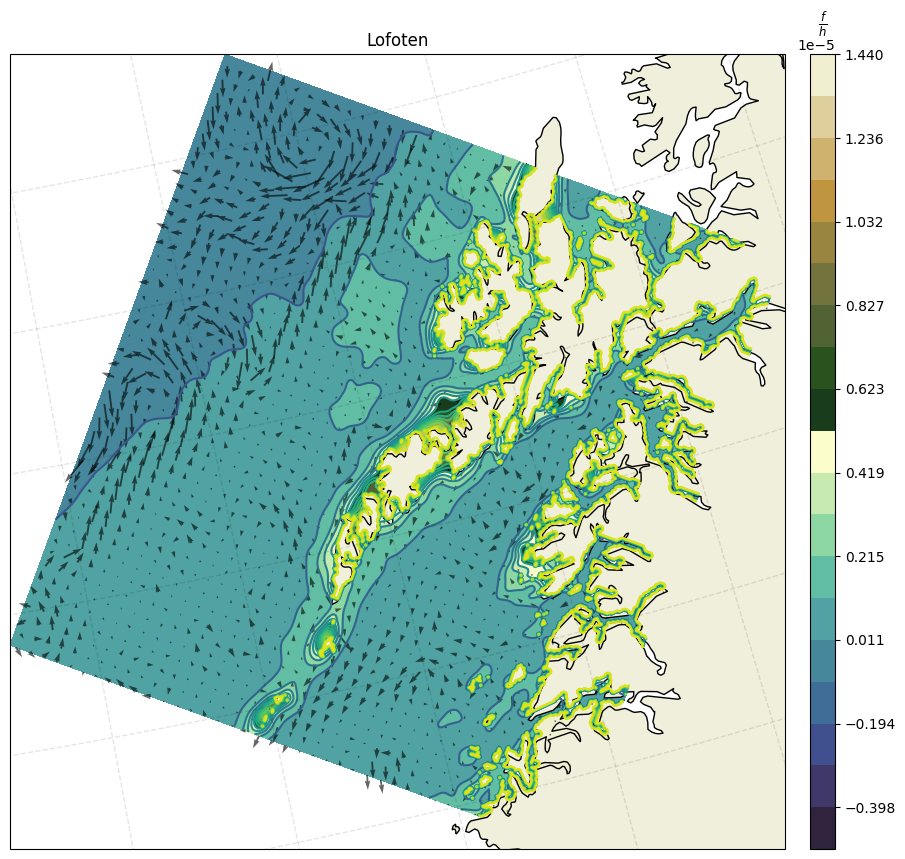

In [160]:
fig,ax = plt.subplots(figsize = (10,12), subplot_kw={'projection': ccrs.NorthPolarStereo()})
im = ax.contour(Lofoten.longitude.values, Lofoten.latitude.values, f_h[0,slice(x_min,x_max+1),slice(y_min, y_max+1)], levels = custom, transform = ccrs.PlateCarree(), zorder = 2, color = 'black')
im2 = ax.contourf(Lofoten.longitude.values, Lofoten.latitude.values, f_h[0,slice(x_min,x_max+1),slice(y_min, y_max+1)], levels = custom, transform = ccrs.PlateCarree(), zorder = 1, cmap = cmocean.cm.topo)
ax.quiver(Lofoten.longitude.values[::step, ::step], Lofoten.latitude.values[::step, ::step], Lofoten.u_eastward_0[0,:,:].values[::step, ::step], Lofoten.v_northward_0[0,:,:].values[::step, ::step], transform = ccrs.PlateCarree(), color = 'black', alpha = 0.6, scale = 20)
cax = fig.add_axes([ax.get_position().x1+0.025, ax.get_position().y0, 0.025, ax.get_position().height])
cbar = fig.colorbar(im2, ax=ax, cax = cax, extend = "both")
gl = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels = False, linewidth = 1, color = 'black', alpha = 0.1, linestyle = '--')
gl.xlabels_top = False
ax.set_title('Lofoten')
cbar.ax.set_title(r'$\frac{f}{h}$')
ax.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = 'black')

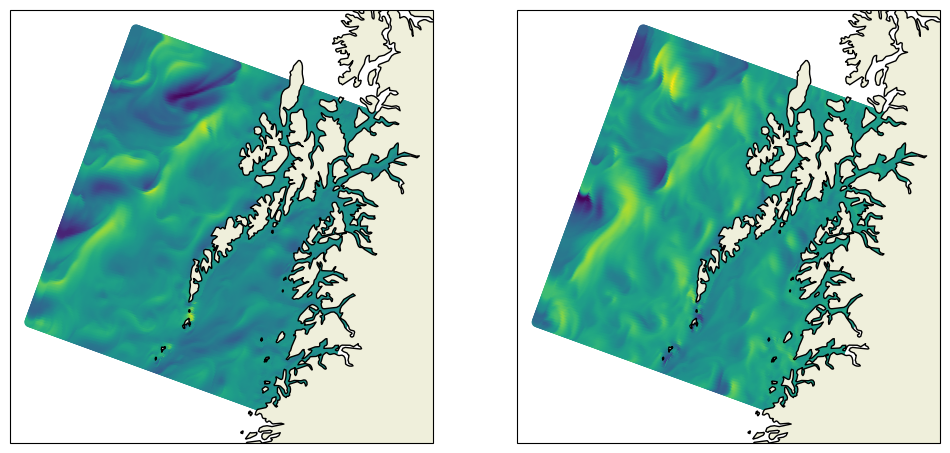

In [41]:
fig,ax = plt.subplots(1,2, figsize = (12,16), subplot_kw={'projection': ccrs.NorthPolarStereo()})
im1 = ax[0].scatter(Lofoten.longitude.values, Lofoten.latitude.values, c = Lofoten.u_eastward_0[0,:,:].values, transform = ccrs.PlateCarree())
im2 = ax[1].scatter(Lofoten.longitude.values, Lofoten.latitude.values, c = Lofoten.v_northward_0[0,:,:].values, transform = ccrs.PlateCarree())
for i in range(0,2):
    ax[i].add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = 'black')